In [57]:
import os
import json
import joblib
import sys
import numpy as np
import pandas as pd
import glob
import gc
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import tensorflow as tf
import warnings
from data_loader import DataLoader

warnings.filterwarnings('ignore')

# Helper Functions

In [58]:
TARGET_COL = "Carbon intensity gCO₂eq/kWh (direct)"
MODEL_CONFIG = {
    'CNN': {
        'window_size': 24,
        'forecast_horizon': 24,
        'features': [TARGET_COL, 'hour_sin', 'hour_cos', 'year_sin', 'year_cos'],
        'model_path': 'carbon_model_cnn_v3.tflite',
        'scaler_path': 'scaler_params_cnn_v3.json'
    },
    'LSTM': {
    'window_size': 168,
    'forecast_horizon': 24,
    'features': [TARGET_COL, 'diff_1', 'diff_24', 'hour_sin', 'hour_cos', 'year_sin', 'year_cos', 'dow_sin', 'dow_cos', 'wind_speed', 'temperature', 'price_eur_mwh'],
    'model_path': 'carbon_model_lstm_v4.tflite',
    'scaler_path': 'scaler_params_v4.json'
    },
    'TCN': {
        'window_size': 336,
        'forecast_horizon': 24,
        'features': ['Carbon intensity gCO₂eq/kWh (Life cycle)', 'Carbon-free energy percentage (CFE%)',
                 'Renewable energy percentage (RE%)', 'hour', 'day_of_year', 'hour_sin', 'hour_cos',
                 'year_sin', 'year_cos', 'day_of_week', 'dow_sin', 'dow_cos', 'diff_1', 'diff_24'],
        'model_path': 'carbon_model_tcn.tflite',
        'scaler_path': 'scaler_params_tcn.json'
    }
}


def open_dataset(path, date_column):
    csv_files = sorted(glob.glob(path))
    dfs = []
    for f in csv_files:
        temp_df = pd.read_csv(f, parse_dates=[date_column])
        dfs.append(temp_df)
    df = pd.concat(dfs, ignore_index=True)
    del dfs
    gc.collect()
    return df


def load_scaler_params(json_path):
    """Load scaler parameters from JSON file"""
    with open(json_path, 'r') as f:
        return json.load(f)


def inverse_scale_target(scaled_values, scaler_params):
    """Inverse scale target predictions"""
    target_mean = np.array(scaler_params['target_mean'])
    target_scale = np.array(scaler_params['target_scale'])
    return scaled_values * target_scale + target_mean


def scale_features(data, scaler_params):
    """Scale features using saved parameters"""
    feature_mean = np.array(scaler_params['feature_mean'])
    feature_scale = np.array(scaler_params['feature_scale'])
    return (data - feature_mean) / feature_scale


def create_sequences(data, window_size):
    """Create sequences for neural network prediction"""
    x = []
    for i in range(len(data) - window_size + 1):
        x.append(data[i:i + window_size])
    return np.array(x)

# Load & Preprocess Data
## Carbon emissions

In [59]:
loader = DataLoader()
df = loader.merge_all()

# Create all features
df["hour"] = df["Datetime (UTC)"].dt.hour
df["day_of_year"] = df["Datetime (UTC)"].dt.dayofyear
df["day_of_week"] = df["Datetime (UTC)"].dt.dayofweek
df["month"] = df["Datetime (UTC)"].dt.month

# Cyclical encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Differencing
df["diff_1"] = df[TARGET_COL].diff(1)
df["diff_24"] = df[TARGET_COL].diff(24)

df = df.drop(columns=["Data estimated", "Country", "Zone name", "Data source", "Data estimation method"],
             errors='ignore')
df = df.dropna()  # ← Drop NaN FIRST

# Get test data
test_df = df[df["Datetime (UTC)"].dt.year == 2025].copy()
test_df["dow"] = test_df["day_of_week"]
test_dates = test_df["Datetime (UTC)"]
y_test_actual = test_df[TARGET_COL].astype(np.float32).values  # ← Now from clean df!

print(f"Loaded data with {len(df)} total rows (after dropna)")
print(f"Test set: {len(test_df)} samples from {test_dates.min()} to {test_dates.max()}")


=== Loading Complete Dataset ===
Emissions: 43824 rows, 2021-01-01 00:00:00 to 2025-12-31 23:00:00
Columns: ['Datetime (UTC)', 'Country', 'Zone name', 'Zone id', 'Carbon intensity gCO₂eq/kWh (direct)', 'Carbon intensity gCO₂eq/kWh (Life cycle)', 'Carbon-free energy percentage (CFE%)', 'Renewable energy percentage (RE%)', 'Data source', 'Data estimated', 'Data estimation method']
Loading DMI weather data...
  wind_speed: 52609 hours, 57 stations
  temperature: 52609 hours, 61 stations
Loading electricity prices...
  Old format: 41303 rows
  New format (resampled): 8760 rows
Combined: 43825 rows, 2020-12-31 23:00:00 to 2025-12-31 23:00:00

Merged: 43824 rows before feature engineering
Loaded data with 43800 total rows (after dropna)
Test set: 8760 samples from 2025-01-01 00:00:00 to 2025-12-31 23:00:00


# Load Models

## Load SARIMA Model

In [60]:
models = {}
scaler_params = {}

predictions = {'Actual': y_test_actual}

# Load SARIMA first (doesn't depend on feature scaling)
print("\n[SARIMA]")
try:
    sarima_model = joblib.load('export_sarima/sarima_model.joblib')
    sarima_feature_scaler = joblib.load('export_sarima/sarima_feature_scaler.joblib')
    sarima_target_scaler = joblib.load('export_sarima/sarima_target_scaler.joblib')

    SARIMA_FEATURES = ['hour', 'dow', 'month', 'hour_sin', 'hour_cos',
                       'year_sin', 'year_cos', 'diff_1', 'diff_24']

    # DON'T drop NaN again - already clean from df.dropna()
    X_sarima = test_df[SARIMA_FEATURES].astype(np.float32)

    # Scale exogenous features using the saved scaler
    X_sarima_scaled = pd.DataFrame(
        sarima_feature_scaler.transform(X_sarima),
        columns=SARIMA_FEATURES
    )

    # Reset index for SARIMA
    X_sarima_scaled = X_sarima_scaled.reset_index(drop=True)

    # Make forecast
    sarima_pred_scaled = sarima_model.get_forecast(
        steps=len(X_sarima_scaled),
        exog=X_sarima_scaled
    ).predicted_mean

    # ✗ DON'T inverse transform - predictions are already unscaled!
    sarima_pred = sarima_pred_scaled.values  # ← Just use directly

    predictions['SARIMA'] = sarima_pred  # ← NO PADDING needed!

    print(f"Predictions made: {sarima_pred.shape}")
except Exception as e:
    print(f"Failed: {e}")
    import traceback
    traceback.print_exc()

# CNN Predictions
print("\n[CNN]")
try:
    scaler_params['CNN'] = load_scaler_params(MODEL_CONFIG['CNN']['scaler_path'])
    config = MODEL_CONFIG['CNN']

    # Get CNN's features including target
    X_cnn_raw = test_df[config['features']].astype(np.float32).values

    # Scale: target uses target_mean/scale, other features use feature_mean/scale
    X_cnn_scaled = np.zeros_like(X_cnn_raw)
    # Scale target (first column)
    X_cnn_scaled[:, 0] = (X_cnn_raw[:, 0] - scaler_params['CNN']['target_mean'][0]) / scaler_params['CNN']['target_scale'][0]
    # Scale features (remaining columns)
    X_cnn_scaled[:, 1:] = scale_features(X_cnn_raw[:, 1:], scaler_params['CNN'])

    X_cnn_seq = create_sequences(X_cnn_scaled, config['window_size'])

    # Load model
    interpreter = tf.lite.Interpreter(model_path=config['model_path'])
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Make predictions
    cnn_pred_list = []
    for i in range(len(X_cnn_seq)):  # ← Loop through sequences, not raw data!
        interpreter.set_tensor(input_details[0]['index'], X_cnn_seq[i:i + 1].astype(np.float32))
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        cnn_pred_list.append(output[0][0])

    cnn_pred_scaled = np.array(cnn_pred_list)
    cnn_pred = inverse_scale_target(cnn_pred_scaled, scaler_params['CNN'])

    # Pad to match test length
    offset = len(y_test_actual) - len(cnn_pred)
    cnn_pred_full = np.concatenate([np.full(offset, np.nan), cnn_pred])
    predictions['CNN'] = cnn_pred_full

    print(f"Predictions made: {cnn_pred.shape} (padded to {cnn_pred_full.shape})")
except Exception as e:
    print(f"Failed: {e}")
    import traceback
    traceback.print_exc()

# LSTM Predictions
print("\n[LSTM]")
try:
    lstm_scaler_raw = load_scaler_params(MODEL_CONFIG['LSTM']['scaler_path'])
    config = MODEL_CONFIG['LSTM']

    scaler_params['LSTM'] = {
        'target_mean': np.array(lstm_scaler_raw['target_mean']),
        'target_scale': np.array(lstm_scaler_raw['target_scale'])
    }

    # Get LSTM's features including target
    X_lstm_raw = test_df[config['features']].astype(np.float32).values

    # Scale: target uses target_mean/scale, other features are already in diffs/cyclical
    X_lstm_scaled = X_lstm_raw.copy()
    # Scale target (first column) only
    X_lstm_scaled[:, 0] = (X_lstm_raw[:, 0] - scaler_params['LSTM']['target_mean'][0]) / scaler_params['LSTM']['target_scale'][0]

    # Create sequences with LSTM's window size
    X_lstm_seq = create_sequences(X_lstm_scaled, config['window_size'])

    # Load model
    interpreter = tf.lite.Interpreter(model_path=config['model_path'])
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    print(f"Input shape expected: {input_details[0]['shape']}")
    print(f"X_lstm_seq shape: {X_lstm_seq.shape}")

    # Make predictions
    lstm_pred_list = []
    for i in range(len(X_lstm_seq)):
        interpreter.set_tensor(input_details[0]['index'], X_lstm_seq[i:i + 1].astype(np.float32))
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        lstm_pred_list.append(output[0][0])

    lstm_pred_scaled = np.array(lstm_pred_list)
    lstm_pred = inverse_scale_target(lstm_pred_scaled, scaler_params['LSTM'])

    # Pad to match test length
    offset = len(y_test_actual) - len(lstm_pred)
    lstm_pred_full = np.concatenate([np.full(offset, np.nan), lstm_pred])
    predictions['LSTM'] = lstm_pred_full

    print(f"Predictions made: {lstm_pred.shape} (padded to {lstm_pred_full.shape})")
    print(f"    Features used: {config['features']}")
except Exception as e:
    print(f"Failed: {e}")
    import traceback
    traceback.print_exc()

# TCN Predictions
print("\n[TCN]")
try:
    scaler_params['TCN'] = load_scaler_params(MODEL_CONFIG['TCN']['scaler_path'])
    config = MODEL_CONFIG['TCN']

    # Get TCN's features (WITHOUT target)
    X_tcn_raw = test_df[config['features']].astype(np.float32).values

    # Scale features only
    X_tcn_scaled = scale_features(X_tcn_raw, scaler_params['TCN'])

    # Create sequences with TCN's window size
    X_tcn_seq = create_sequences(X_tcn_scaled, config['window_size'])

    # Load model
    interpreter = tf.lite.Interpreter(model_path=config['model_path'])
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    print(f"Input shape expected: {input_details[0]['shape']}")
    print(f"X_tcn_seq shape: {X_tcn_seq.shape}")

    # Make predictions
    tcn_pred_list = []
    for i in range(len(X_tcn_seq)):
        interpreter.set_tensor(input_details[0]['index'], X_tcn_seq[i:i + 1].astype(np.float32))
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        tcn_pred_list.append(output[0][0])

    tcn_pred_scaled = np.array(tcn_pred_list)
    tcn_pred = inverse_scale_target(tcn_pred_scaled, scaler_params['TCN'])

    # Pad to match test length
    offset = len(y_test_actual) - len(tcn_pred)
    tcn_pred_full = np.concatenate([np.full(offset, np.nan), tcn_pred])
    predictions['TCN'] = tcn_pred_full

    print(f"Predictions made: {tcn_pred.shape} (padded to {tcn_pred_full.shape})")
    print(f"    Features used: {config['features']}")
except Exception as e:
    print(f"Failed: {e}")
    import traceback
    traceback.print_exc()


[SARIMA]
Predictions made: (8760,)

[CNN]
Predictions made: (8737,) (padded to (8760,))

[LSTM]
Input shape expected: [  1 168  12]
X_lstm_seq shape: (8593, 168, 12)
Predictions made: (8593,) (padded to (8760,))
    Features used: ['Carbon intensity gCO₂eq/kWh (direct)', 'diff_1', 'diff_24', 'hour_sin', 'hour_cos', 'year_sin', 'year_cos', 'dow_sin', 'dow_cos', 'wind_speed', 'temperature', 'price_eur_mwh']

[TCN]
Input shape expected: [  1 336  14]
X_tcn_seq shape: (8425, 336, 14)
Predictions made: (8425,) (padded to (8760,))
    Features used: ['Carbon intensity gCO₂eq/kWh (Life cycle)', 'Carbon-free energy percentage (CFE%)', 'Renewable energy percentage (RE%)', 'hour', 'day_of_year', 'hour_sin', 'hour_cos', 'year_sin', 'year_cos', 'day_of_week', 'dow_sin', 'dow_cos', 'diff_1', 'diff_24']


# Calculate Metrics

In [61]:
results = {}

print(f"\n{'Model':<10} {'MAE':<12} {'RMSE':<12} {'MAPE':<10} {'R²':<10} {'Samples':<10}")
print("-" * 65)

for model_name, pred in predictions.items():
    if model_name == 'Actual':
        continue

    if pred is None:
        print(f"{model_name:<10} {'FAILED':<12}")
        continue

    # Handle sequences with NaN padding (CNN, LSTM, TCN only)
    if model_name in ['CNN', 'LSTM', 'TCN']:
        mask = ~np.isnan(pred)
        y_true = y_test_actual[mask]
        y_pred = pred[mask]
    else:  # SARIMA has no NaN now
        y_true = y_test_actual
        y_pred = pred

    if len(y_pred) == 0:
        print(f"{model_name:<10} {'NO DATA':<12}")
        continue

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)

    results[model_name] = {
        'MAE': float(mae),
        'RMSE': float(rmse),
        'MAPE': float(mape),
        'R2': float(r2),
        'num_samples': len(y_pred)
    }

    print(f"{model_name:<10} {mae:<12.4f} {rmse:<12.4f} {mape:<10.2f}% {r2:<10.4f} {len(y_pred):<10}")


Model      MAE          RMSE         MAPE       R²         Samples   
-----------------------------------------------------------------
SARIMA     72.9145      79.3195      112.32    % -3.4636    8760      
CNN        8.3040       11.6550      11.69     % 0.9037     8737      
LSTM       33.3141      38.5236      67.00     % -0.0440    8593      
TCN        20.4913      26.5918      33.88     % 0.4966     8425      


In [62]:
full_year_preds = {
    'SARIMA': predictions.get('SARIMA'),
    'CNN': predictions.get('CNN'),
    'LSTM': predictions.get('LSTM'),
    'TCN': predictions.get('TCN')
}

# Verify all are present and full-length
print("\n✓ Saved full-year predictions:")
for model_name in ['SARIMA', 'CNN', 'LSTM', 'TCN']:
    if full_year_preds[model_name] is not None:
        print(f"  {model_name}: {len(full_year_preds[model_name])} predictions")
    else:
        print(f"  {model_name}: NONE")


✓ Saved full-year predictions:
  SARIMA: 8760 predictions
  CNN: 8760 predictions
  LSTM: 8760 predictions
  TCN: 8760 predictions


# Visualisation - Full Year Comparison

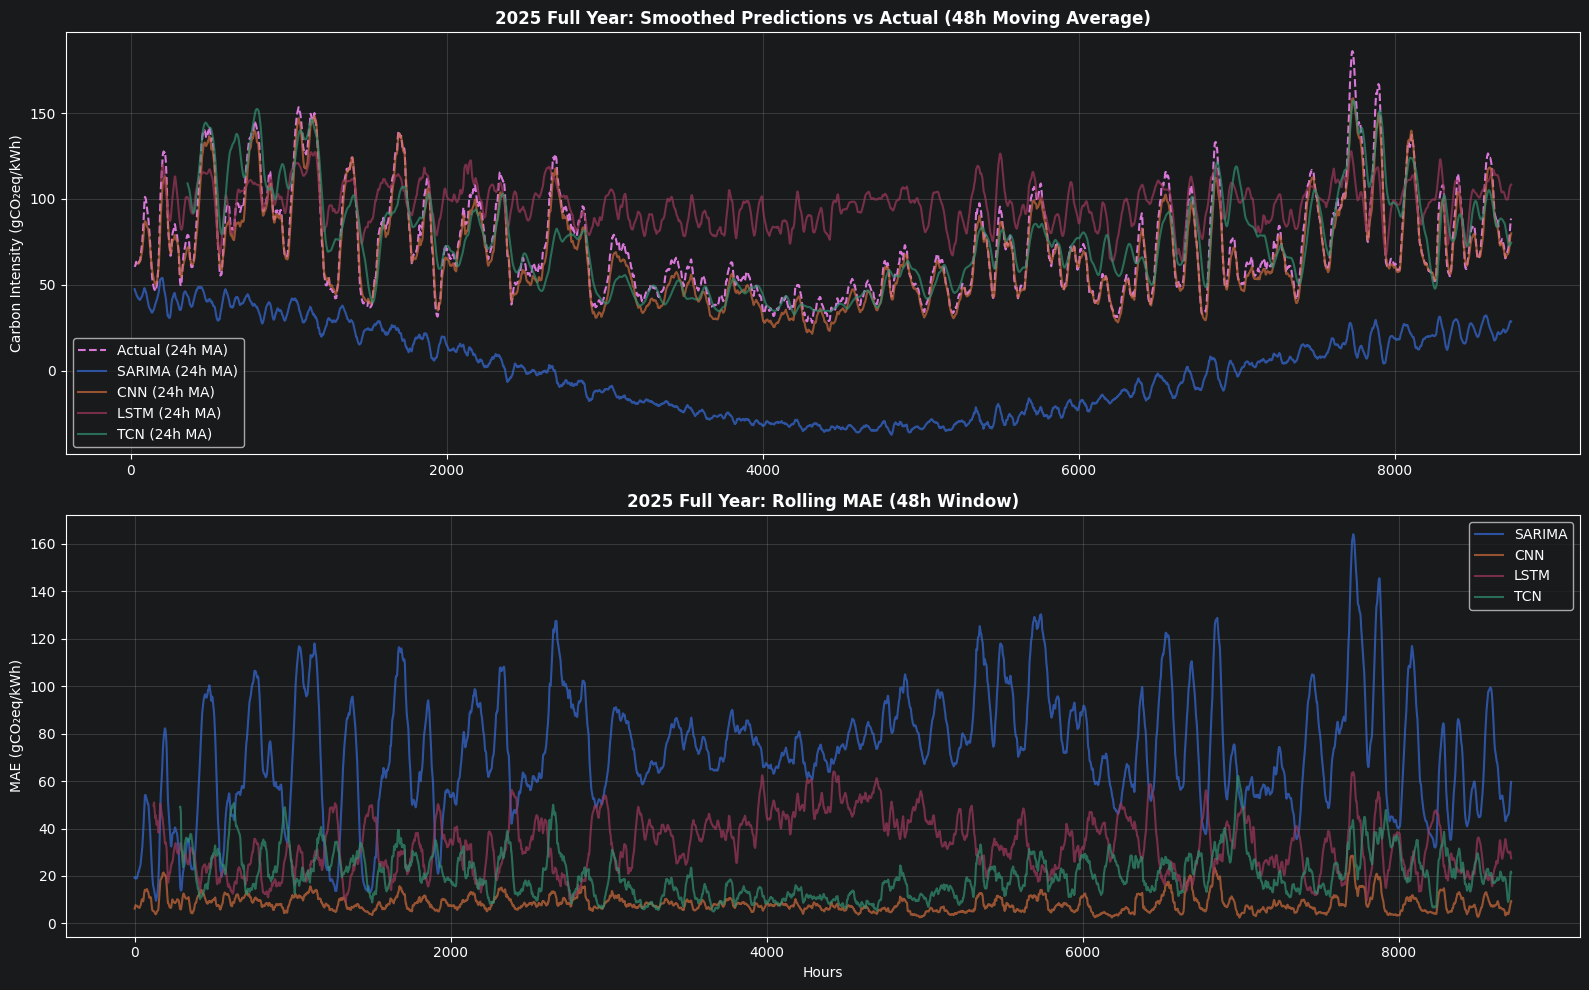

In [77]:
window_smooth = 48
window_mae = 48

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Top: Smoothed predictions vs actual
smoothed_actual = pd.Series(y_test_actual).rolling(window=window_smooth, center=True).mean()
ax1.plot(range(len(smoothed_actual)), smoothed_actual, label='Actual (24h MA)',
         linewidth=1.5, color='violet', linestyle='dashed', alpha=0.9)

for model_name in ['SARIMA', 'CNN', 'LSTM', 'TCN']:
    if full_year_preds[model_name] is not None:
        pred_series = pd.Series(full_year_preds[model_name])
        smoothed_pred = pred_series.rolling(window=window_smooth, center=True).mean()
        ax1.plot(range(len(smoothed_pred)), smoothed_pred,
                label=f'{model_name} (24h MA)', alpha=0.7, linewidth=1.5)

ax1.set_title('2025 Full Year: Smoothed Predictions vs Actual (48h Moving Average)',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Carbon Intensity (gCO₂eq/kWh)')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Bottom: Rolling MAE
for model_name in ['SARIMA', 'CNN', 'LSTM', 'TCN']:
    if full_year_preds[model_name] is not None:
        pred = np.asarray(full_year_preds[model_name], dtype=np.float32)
        rolling_mae = []

        for i in range(len(y_test_actual) - window_mae):
            window_actual = y_test_actual[i:i+window_mae].astype(np.float32)
            window_pred = pred[i:i+window_mae].astype(np.float32)

            valid_mask = ~np.isnan(window_pred)

            if np.sum(valid_mask) > 0:
                mae = mean_absolute_error(
                    window_actual[valid_mask],
                    window_pred[valid_mask]
                )
                rolling_mae.append(mae)
            else:
                rolling_mae.append(np.nan)

        ax2.plot(range(len(rolling_mae)), rolling_mae, label=model_name,
                alpha=0.7, linewidth=1.5)

ax2.set_title('2025 Full Year: Rolling MAE (48h Window)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Hours')
ax2.set_ylabel('MAE (gCO₂eq/kWh)')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualization - MAE Comparison

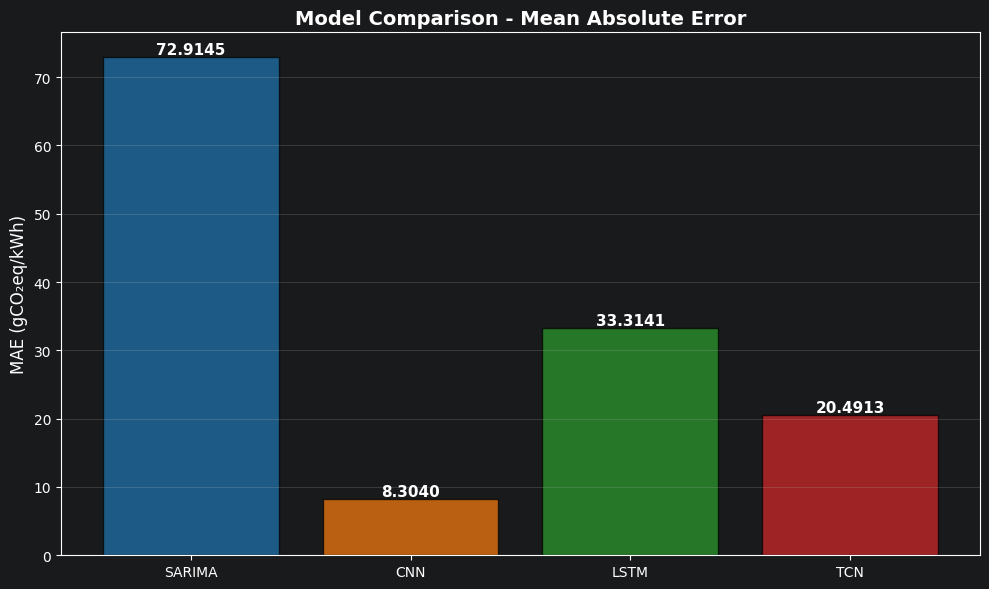

In [64]:
if results:
    fig, ax = plt.subplots(figsize=(10, 6))
    models_list = list(results.keys())
    maes = [results[m]['MAE'] for m in models_list]

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    bars = ax.bar(models_list, maes, color=colors[:len(models_list)], alpha=0.7, edgecolor='black')

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('MAE (gCO₂eq/kWh)', fontsize=12)
    ax.set_title('Model Comparison - Mean Absolute Error', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# Visualisation - Training Curves Comparison

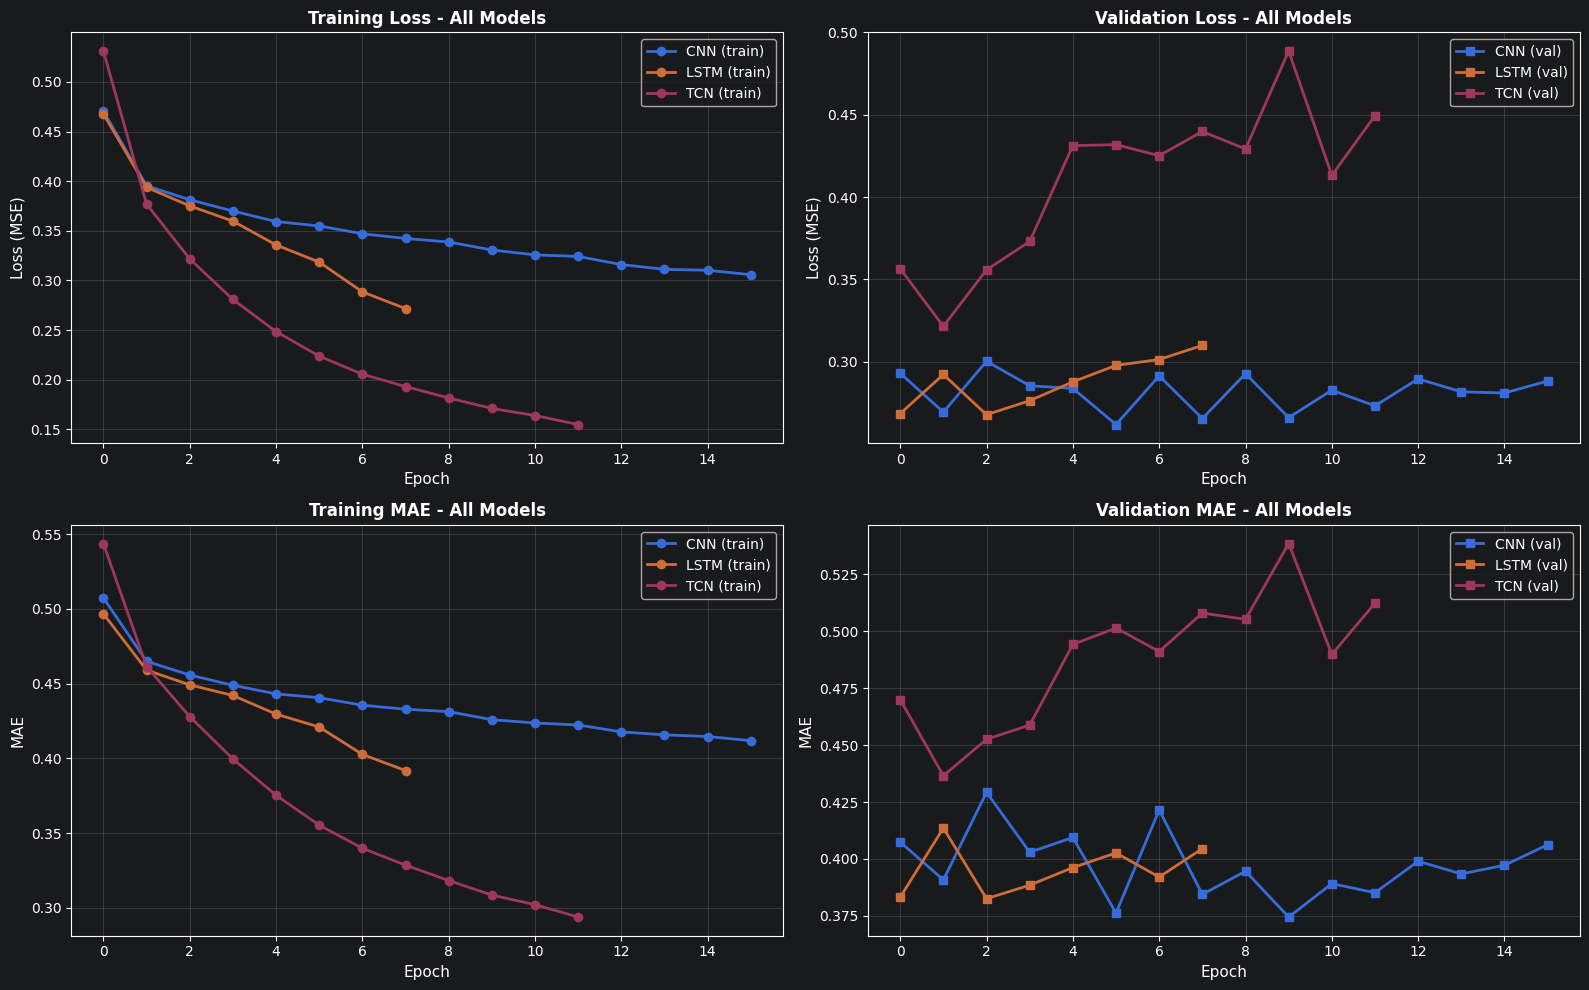


CNN:
  Best epoch: 5
  Best val_loss: 0.261865
  Best val_mae: 0.376171
  Final train_loss: 0.305846
  Final val_loss: 0.288292

LSTM:
  Best epoch: 2
  Best val_loss: 0.267856
  Best val_mae: 0.382517
  Final train_loss: 0.271711
  Final val_loss: 0.309961

TCN:
  Best epoch: 1
  Best val_loss: 0.321527
  Best val_mae: 0.436534
  Final train_loss: 0.154926
  Final val_loss: 0.449480


In [65]:
MODEL_LOGS = {
    'CNN': 'training_log_cnn.csv',
    'LSTM': 'training_log_lstm.csv',
    'TCN': 'training_log_tcn.csv',
}

# Load training histories
training_histories = {}
for model_name, log_file in MODEL_LOGS.items():
    training_histories[model_name] = pd.read_csv(log_file)


# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Training Loss Comparison
ax = axes[0, 0]
for model_name, history in training_histories.items():
    ax.plot(history['epoch'], history['loss'], marker='o', label=f'{model_name} (train)', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss (MSE)', fontsize=11)
ax.set_title('Training Loss - All Models', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Plot 2: Validation Loss Comparison
ax = axes[0, 1]
for model_name, history in training_histories.items():
    ax.plot(history['epoch'], history['val_loss'], marker='s', label=f'{model_name} (val)', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss (MSE)', fontsize=11)
ax.set_title('Validation Loss - All Models', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Plot 3: Training MAE Comparison
ax = axes[1, 0]
for model_name, history in training_histories.items():
    ax.plot(history['epoch'], history['mae'], marker='o', label=f'{model_name} (train)', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('MAE', fontsize=11)
ax.set_title('Training MAE - All Models', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Plot 4: Validation MAE Comparison
ax = axes[1, 1]
for model_name, history in training_histories.items():
    ax.plot(history['epoch'], history['val_mae'], marker='s', label=f'{model_name} (val)', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('MAE', fontsize=11)
ax.set_title('Validation MAE - All Models', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: Print summary statistics

for model_name, history in training_histories.items():
    best_val_loss_idx = history['val_loss'].idxmin()
    print(f"\n{model_name}:")
    print(f"  Best epoch: {int(history.loc[best_val_loss_idx, 'epoch'])}")
    print(f"  Best val_loss: {history.loc[best_val_loss_idx, 'val_loss']:.6f}")
    print(f"  Best val_mae: {history.loc[best_val_loss_idx, 'val_mae']:.6f}")
    print(f"  Final train_loss: {history.iloc[-1]['loss']:.6f}")
    print(f"  Final val_loss: {history.iloc[-1]['val_loss']:.6f}")

# Visualisation - Sample 24h Forecast Comparison

Sample: 2025-07-01 12:00:00 to 2025-07-02 11:00:00

[SARIMA]
[CNN]
[LSTM]
[TCN]


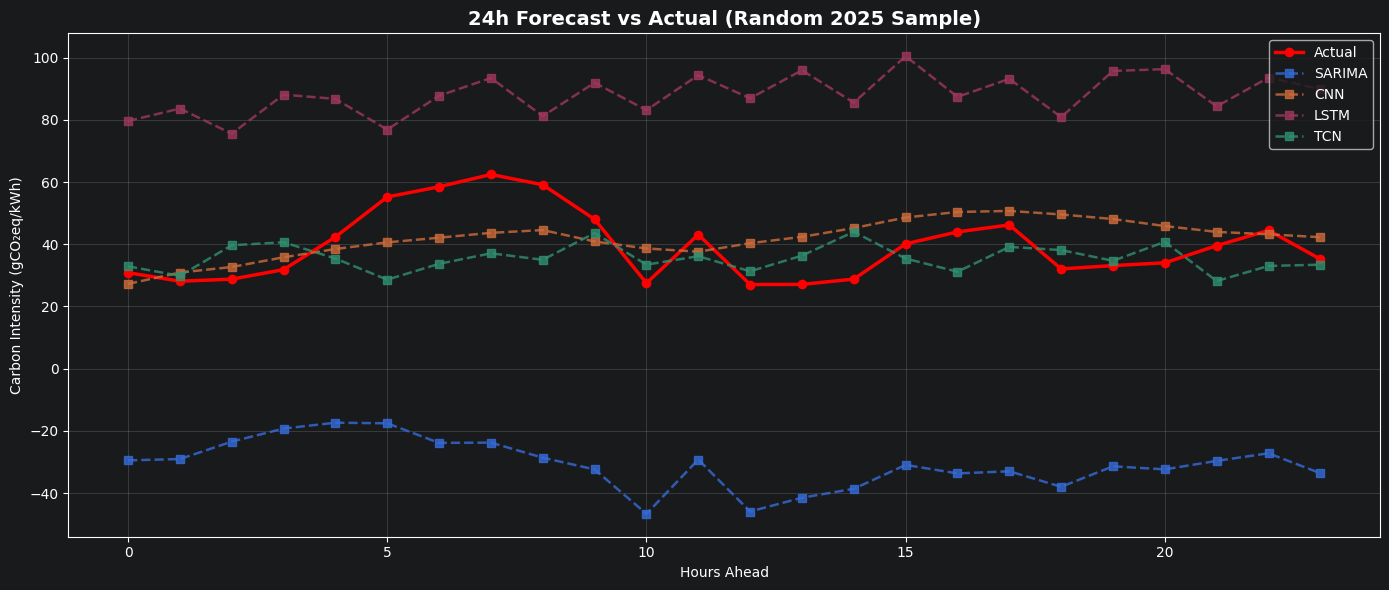


Model      MAE        MAPE      
------------------------------
SARIMA     70.1685    186.09    %
CNN        9.4824     25.43     %
LSTM       48.5280    138.03    %
TCN        10.0309    23.96     %


In [67]:
max_window = max(336, 168)  # CNN/TCN: 336, LSTM: 168
valid_start = max_window
valid_end = len(test_df) - 24

idx = np.random.randint(valid_start, valid_end)

# Get history + 24h sample together
history_start = idx - max_window
data_slice = test_df.iloc[history_start:idx+24].copy()

y_actual = data_slice.iloc[-24:][TARGET_COL].values

print(f"Sample: {data_slice['Datetime (UTC)'].iloc[-24]} to {data_slice['Datetime (UTC)'].iloc[-1]}\n")

predictions = {}

# SARIMA (no history needed)
print("[SARIMA]")
try:
    input_sample = data_slice.iloc[-24:].copy()
    X_sarima = input_sample[SARIMA_FEATURES].astype(np.float32)
    X_sarima_scaled = pd.DataFrame(sarima_feature_scaler.transform(X_sarima), columns=SARIMA_FEATURES).reset_index(drop=True)
    pred = sarima_model.get_forecast(steps=len(X_sarima_scaled), exog=X_sarima_scaled).predicted_mean.values
    predictions['SARIMA'] = pred
except Exception as e:
    print(f"✗ {e}")

# CNN (needs 336 rows history)
print("[CNN]")
try:
    X_cnn_raw = data_slice[MODEL_CONFIG['CNN']['features']].astype(np.float32).values
    X_cnn_scaled = np.zeros_like(X_cnn_raw)
    X_cnn_scaled[:, 0] = (X_cnn_raw[:, 0] - scaler_params['CNN']['target_mean'][0]) / scaler_params['CNN']['target_scale'][0]
    X_cnn_scaled[:, 1:] = scale_features(X_cnn_raw[:, 1:], scaler_params['CNN'])
    X_cnn_seq = create_sequences(X_cnn_scaled, MODEL_CONFIG['CNN']['window_size'])

    interpreter = tf.lite.Interpreter(model_path=MODEL_CONFIG['CNN']['model_path'])
    interpreter.allocate_tensors()
    interpreter.set_tensor(interpreter.get_input_details()[0]['index'], X_cnn_seq[-1:].astype(np.float32))
    interpreter.invoke()
    pred_scaled = interpreter.get_tensor(interpreter.get_output_details()[0]['index'])[0]
    predictions['CNN'] = inverse_scale_target(pred_scaled, scaler_params['CNN'])
except Exception as e:
    print(f"✗ {e}")

# LSTM (needs 168 rows history)
print("[LSTM]")
try:
    X_lstm_raw = data_slice[MODEL_CONFIG['LSTM']['features']].astype(np.float32).values
    X_lstm_scaled = X_lstm_raw.copy()
    X_lstm_scaled[:, 0] = (X_lstm_raw[:, 0] - scaler_params['LSTM']['target_mean'][0]) / scaler_params['LSTM']['target_scale'][0]
    X_lstm_seq = create_sequences(X_lstm_scaled, MODEL_CONFIG['LSTM']['window_size'])

    interpreter = tf.lite.Interpreter(model_path=MODEL_CONFIG['LSTM']['model_path'])
    interpreter.allocate_tensors()
    interpreter.set_tensor(interpreter.get_input_details()[0]['index'], X_lstm_seq[-1:].astype(np.float32))
    interpreter.invoke()
    pred_scaled = interpreter.get_tensor(interpreter.get_output_details()[0]['index'])[0]
    predictions['LSTM'] = inverse_scale_target(pred_scaled, scaler_params['LSTM'])
except Exception as e:
    print(f"✗ {e}")

# TCN (needs 336 rows history)
print("[TCN]")
try:
    X_tcn_raw = data_slice[MODEL_CONFIG['TCN']['features']].astype(np.float32).values
    X_tcn_scaled = scale_features(X_tcn_raw, scaler_params['TCN'])
    X_tcn_seq = create_sequences(X_tcn_scaled, MODEL_CONFIG['TCN']['window_size'])

    interpreter = tf.lite.Interpreter(model_path=MODEL_CONFIG['TCN']['model_path'])
    interpreter.allocate_tensors()
    interpreter.set_tensor(interpreter.get_input_details()[0]['index'], X_tcn_seq[-1:].astype(np.float32))
    interpreter.invoke()
    pred_scaled = interpreter.get_tensor(interpreter.get_output_details()[0]['index'])[0]
    predictions['TCN'] = inverse_scale_target(pred_scaled, scaler_params['TCN'])
except Exception as e:
    print(f"✗ {e}")

# Plot
plt.figure(figsize=(14, 6))
hours = np.arange(24)

plt.plot(hours, y_actual, 'o-', label='Actual', linewidth=2.5, color='red', markersize=6)
for model_name, pred in predictions.items():
    plt.plot(hours, pred, 's--', label=model_name, linewidth=1.8, alpha=0.8)

plt.title('24h Forecast vs Actual (Random 2025 Sample)', fontsize=14, fontweight='bold')
plt.xlabel('Hours Ahead')
plt.ylabel('Carbon Intensity (gCO₂eq/kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'Model':<10} {'MAE':<10} {'MAPE':<10}")
print("-" * 30)
for model_name, pred in predictions.items():
    mae = mean_absolute_error(y_actual, pred)
    mape = mean_absolute_percentage_error(y_actual, pred) * 100
    print(f"{model_name:<10} {mae:<10.4f} {mape:<10.2f}%")